In [5]:
pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Load data
df = pd.read_csv("usd_pkr_exchange_data.csv", parse_dates=["Date"])


In [8]:
# First few rows
print(df.head())

# Summary info
print(df.info())

# Statistics
print(df.describe())


        Date  USD_to_PKR  Oil_Price  Inflation_Rate  Interest_Rate  \
0 2020-01-05  160.448357  51.255819        9.681472      13.097375   
1 2020-01-12  160.579225  51.527087       12.669634       7.365074   
2 2020-01-19  161.103069  51.967756        9.967162       8.805499   
3 2020-01-26  162.064584  52.353957       10.048442       8.236402   
4 2020-02-02  162.147507  52.649374       12.889882      12.695517   

    Gold_Price  Foreign_Reserves_Billion_USD  KSE_100_Index  
0  1199.770240                     10.191801   35010.210055  
1  1200.973193                     10.223854   35012.080399  
2  1201.320520                     10.561877   34979.382169  
3  1201.544455                     10.476599   34970.348416  
4  1201.351112                     10.886787   34890.700575  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --

Date                            0
USD_to_PKR                      0
Oil_Price                       0
Inflation_Rate                  0
Interest_Rate                   0
Gold_Price                      0
Foreign_Reserves_Billion_USD    0
KSE_100_Index                   0
dtype: int64


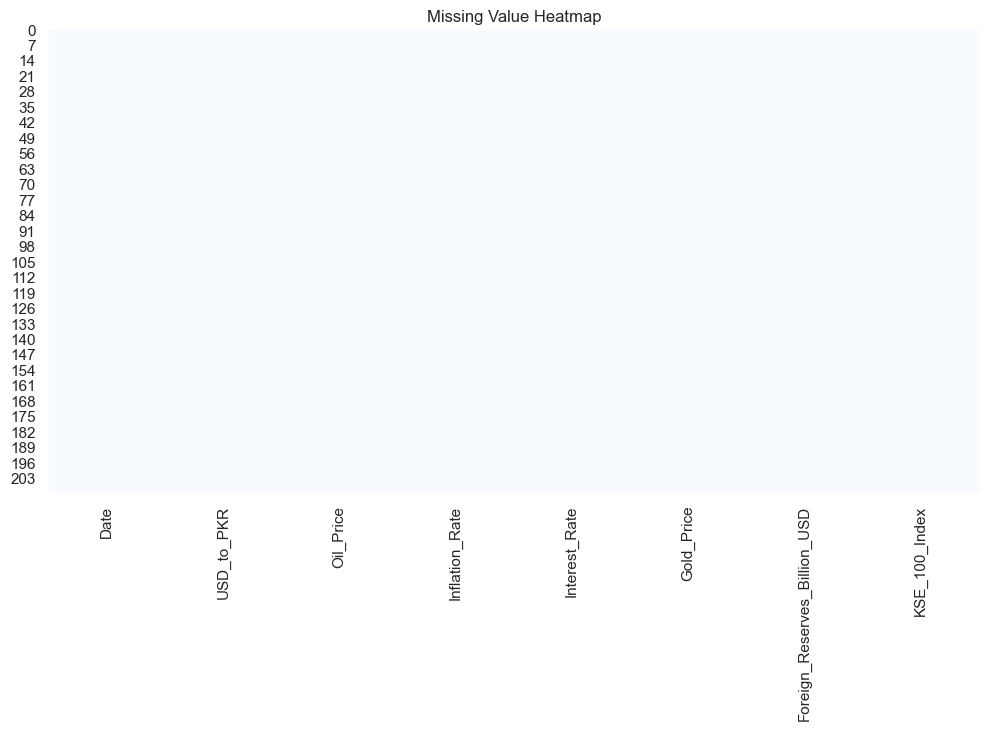

In [9]:
print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Missing Value Heatmap")
plt.show()


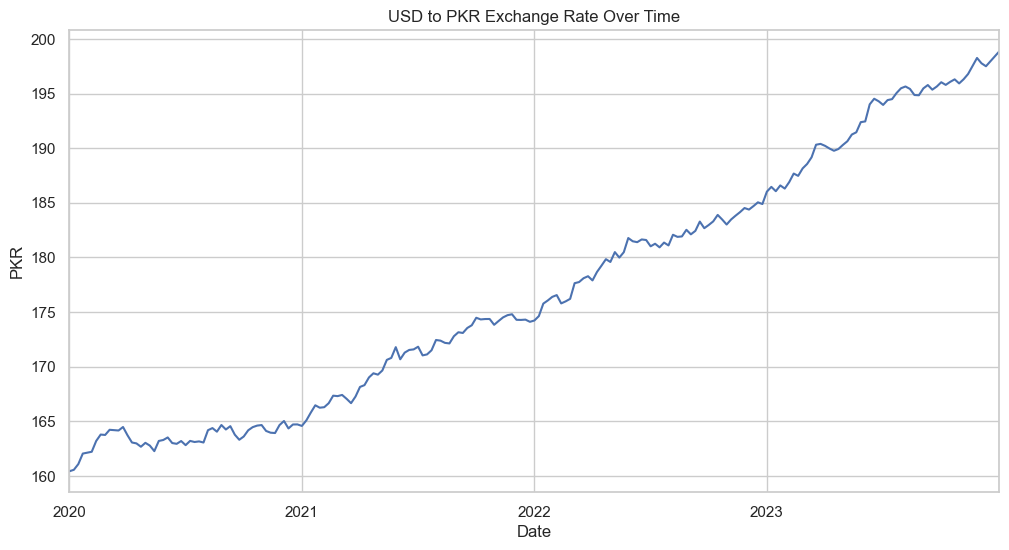

In [10]:
df.set_index('Date', inplace=True)

df['USD_to_PKR'].plot()
plt.title("USD to PKR Exchange Rate Over Time")
plt.ylabel("PKR")
plt.xlabel("Date")
plt.grid(True)
plt.show()


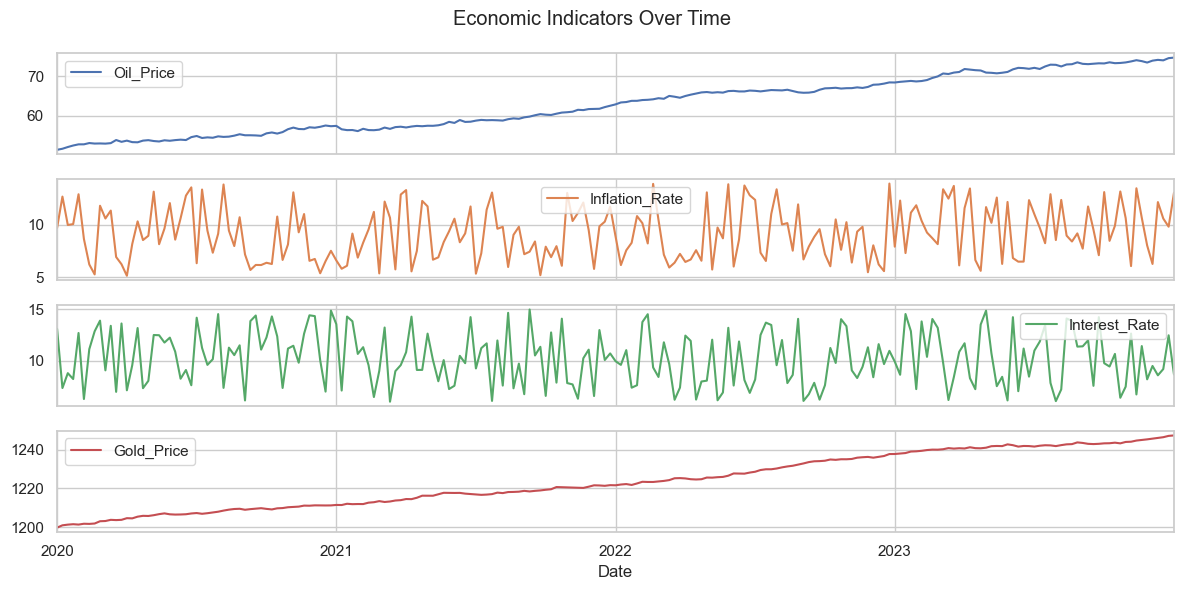

In [11]:
df[['Oil_Price', 'Inflation_Rate', 'Interest_Rate', 'Gold_Price']].plot(subplots=True, title="Economic Indicators Over Time")
plt.tight_layout()
plt.show()


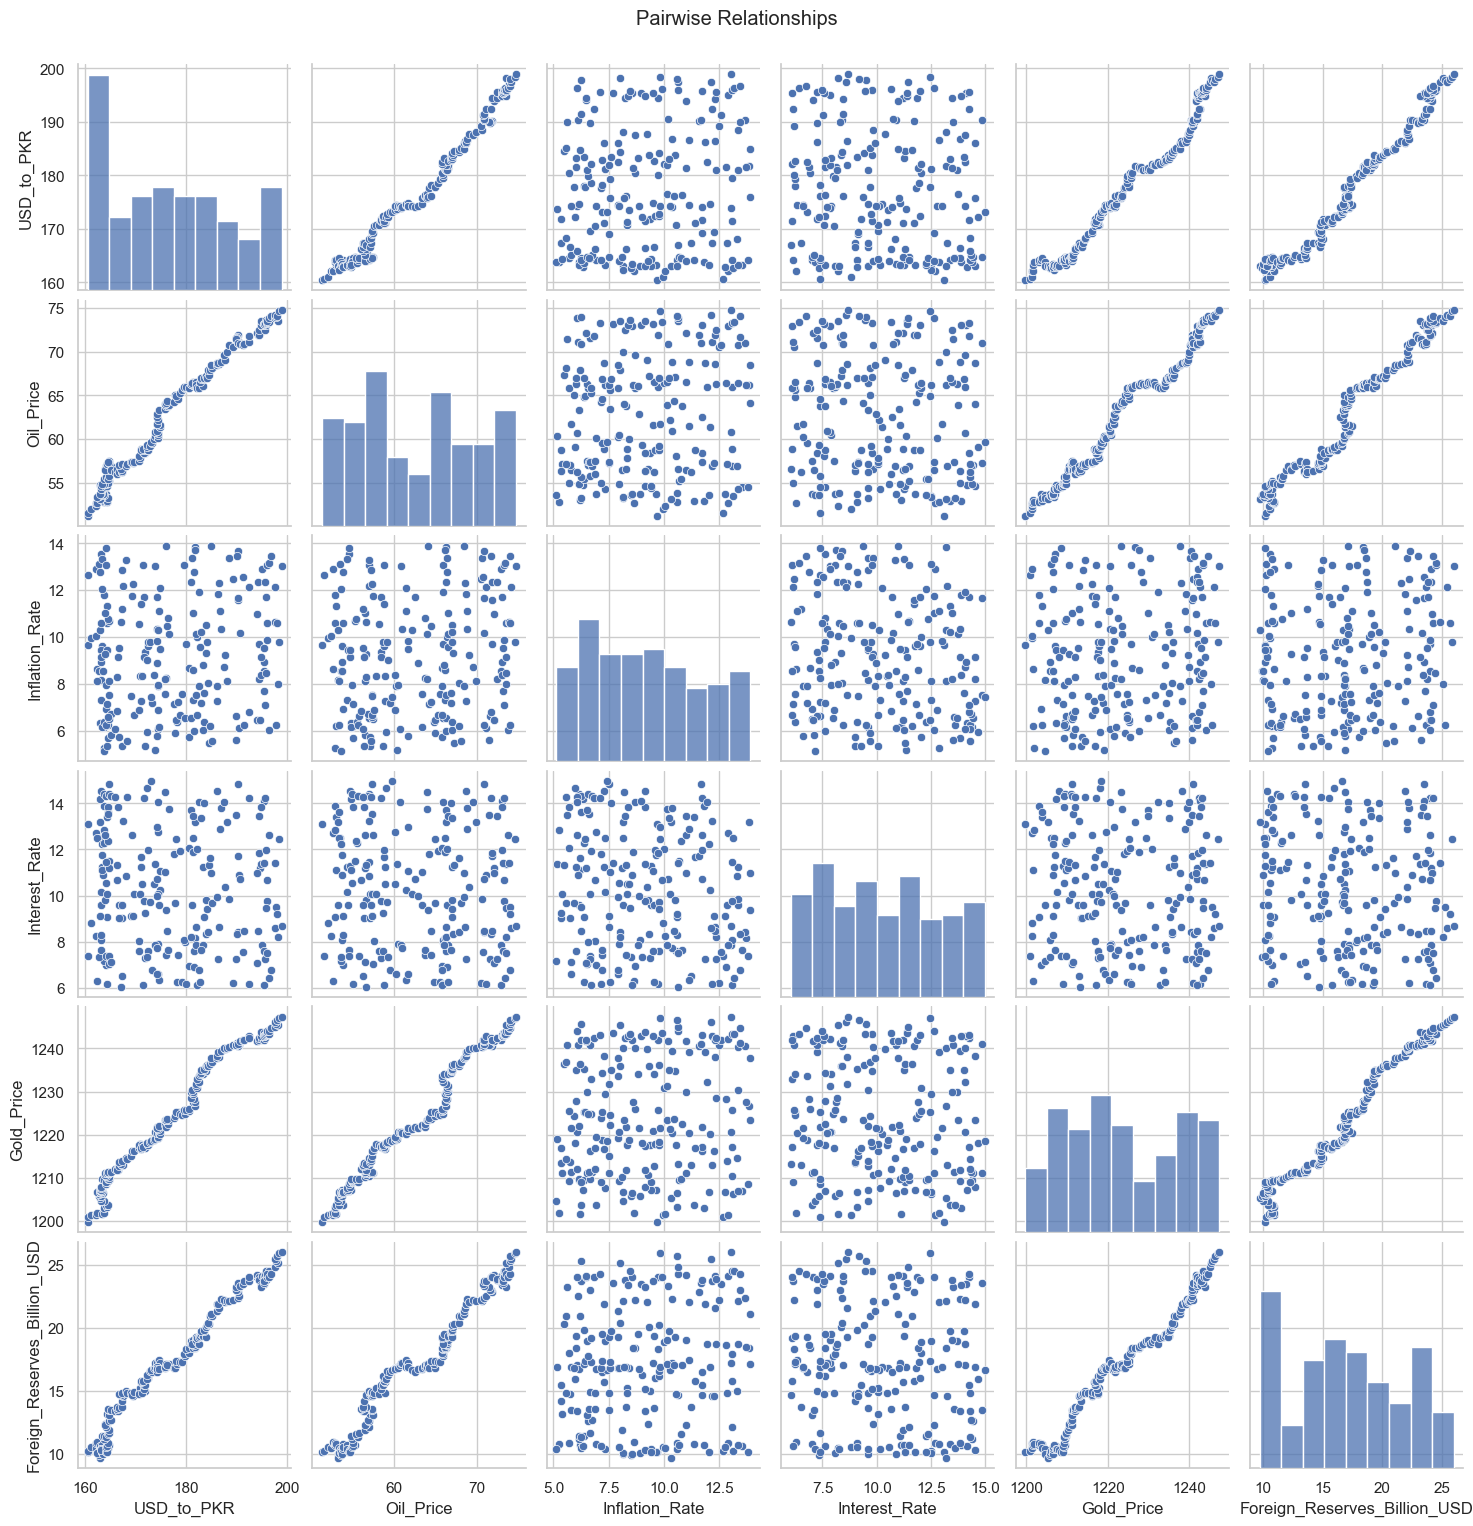

In [12]:
sns.pairplot(df[['USD_to_PKR', 'Oil_Price', 'Inflation_Rate', 'Interest_Rate', 'Gold_Price', 'Foreign_Reserves_Billion_USD']])
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()


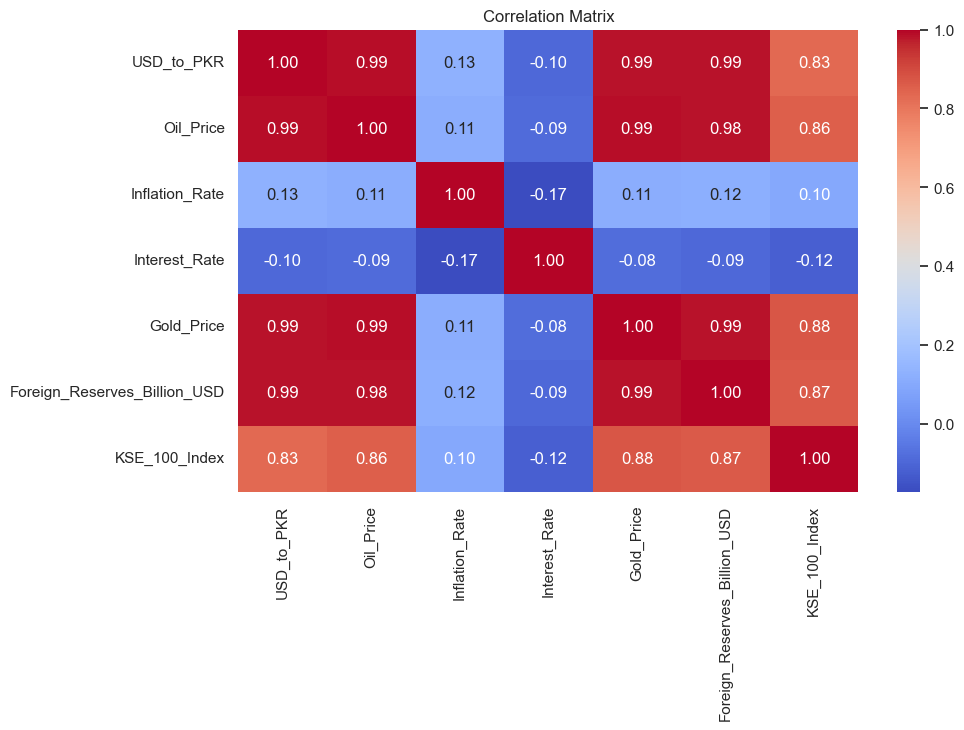

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


In [14]:
usd_corr = df.corr()["USD_to_PKR"].sort_values(ascending=False)
print("Correlation with USD_to_PKR:")
print(usd_corr)


Correlation with USD_to_PKR:
USD_to_PKR                      1.000000
Oil_Price                       0.989572
Gold_Price                      0.986029
Foreign_Reserves_Billion_USD    0.985474
KSE_100_Index                   0.834194
Inflation_Rate                  0.128181
Interest_Rate                  -0.097565
Name: USD_to_PKR, dtype: float64


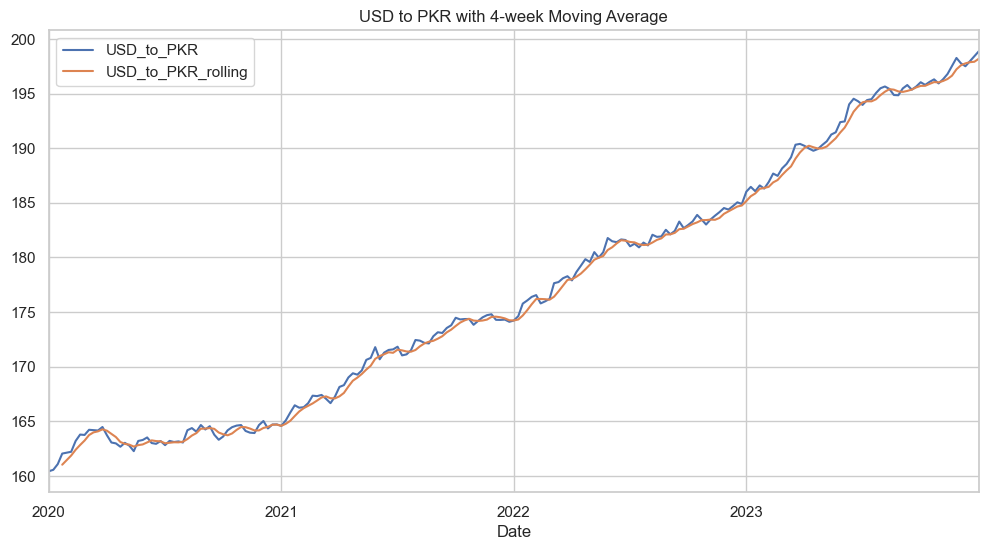

In [15]:
df['USD_to_PKR_rolling'] = df['USD_to_PKR'].rolling(window=4).mean()
df[['USD_to_PKR', 'USD_to_PKR_rolling']].plot()
plt.title("USD to PKR with 4-week Moving Average")
plt.show()


## 📌 Conclusion

Both the **weekly exchange rate (USD to PKR)** and its **rolling average** show a consistent upward trend from 2020 to 2023, confirming a **long-term depreciation** of the **Pakistani Rupee** against the **US Dollar**.

This trend aligns with economic indicators such as declining foreign reserves, rising inflation, and fluctuating oil prices, all of which contribute to weakening currency stability. The analysis highlights the importance of monitoring macroeconomic variables when evaluating currency trends.
